Copyright (C) 2026 Michael Nowotny

This program is free software; you can redistribute it and/or modify
it under the terms of the GNU General Public License version 2 as
published by the Free Software Foundation.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

# The Reverend's Question

*A gentle introduction to Bayesian inference with PyJAGS*

## A Dead Man's Theorem

In 1761, the Reverend Thomas Bayes died in Tunbridge Wells, England. He was a
Presbyterian minister, a Fellow of the Royal Society, and an amateur
mathematician. Among his papers, his friend Richard Price found an unfinished
essay that asked a deceptively simple question:

> *Given that I have observed certain outcomes, what can I infer about the
> process that produced them?*

This is the problem of **inverse probability** -- reasoning backward from
effects to causes. A doctor does it instinctively: given these symptoms,
what is the likely disease? A detective does it at every crime scene: given
this evidence, who likely committed the crime?

Bayes gave humanity the mathematics to do it rigorously. Price edited the
essay and communicated it to the Royal Society in 1763. The idea was so far
ahead of its time that it was largely ignored -- until Pierre-Simon Laplace
independently rediscovered it a decade later and used it to estimate the mass
of Saturn.

In this notebook, you will implement Bayes' theorem from scratch, watch it
learn from data in real time, and discover why -- 260 years later -- it
remains one of the most powerful ideas in all of science.

**What you will learn:**
- How to write a probabilistic model in the BUGS language
- How to draw samples from the posterior distribution using MCMC
- How to visualize and interpret what the data taught us
- Why Bayesian inference gives you not just answers, but *honest uncertainty*

In [1]:
import pyjags
import numpy as np
import arviz as az
import matplotlib.pyplot as plt

pyjags.version_info()

{'pyjags': '2.1.1.dev1+gce081d21a.d20260313',
 'jags': '4.3.1',
 'numpy': '2.4.3',
 'python': '3.12.13',
 'arviz': '1.0.0',
 'h5py': '3.16.0'}

## The Astronomer's Problem

Imagine you are an 18th-century astronomer. You have measured the position
of a star 30 times through your telescope. Each measurement is slightly
different -- the atmosphere shimmers, your hand trembles, the clock drifts.

What is the star's **true** position? And how confident should you be in
your answer?

The frequentist answer: take the average. Simple, elegant -- and limited.
It gives you a single number with no indication of how wrong it might be.

The Bayesian answer: compute the entire **distribution** of plausible
positions, weighted by how well each one explains your observations.
You get not just the best guess, but a full accounting of your uncertainty.

Let us simulate our astronomer's predicament. The star's true position is
at 5.0 (in some arbitrary unit), and our measurements scatter around it
with a standard deviation of 2.0:

In [2]:
np.random.seed(42)

TRUE_POSITION = 5.0
MEASUREMENT_NOISE = 2.0

measurements = np.random.normal(loc=TRUE_POSITION, scale=MEASUREMENT_NOISE, size=30)

print(f"Number of measurements: {len(measurements)}")
print(f"Sample mean:  {measurements.mean():.2f}  (true value: {TRUE_POSITION})")
print(f"Sample stdev: {measurements.std(ddof=1):.2f}  (true value: {MEASUREMENT_NOISE})")

Number of measurements: 30
Sample mean:  4.62  (true value: 5.0)
Sample stdev: 1.80  (true value: 2.0)


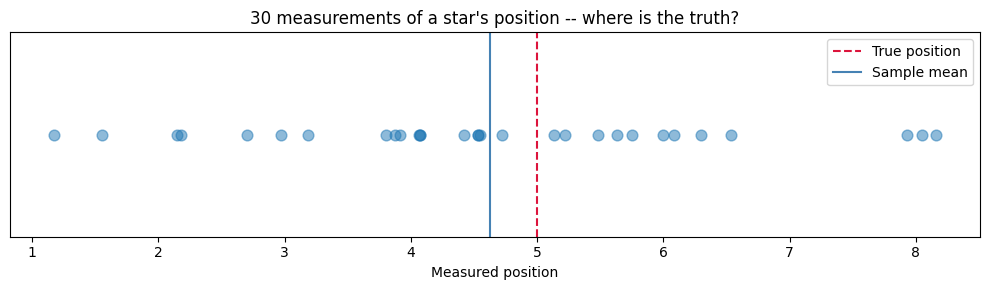

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(measurements, np.zeros_like(measurements), alpha=0.5, s=60, zorder=3)
ax.axvline(TRUE_POSITION, color="crimson", linestyle="--", label="True position")
ax.axvline(measurements.mean(), color="steelblue", linestyle="-", label="Sample mean")
ax.set_xlabel("Measured position")
ax.set_yticks([])
ax.legend()
ax.set_title("30 measurements of a star's position -- where is the truth?")
plt.tight_layout()
plt.show()

The sample mean is close to the truth, but not exact. And we have no sense of
*how close*. Could the true position be 4.0? 6.0? 3.5?

A Bayesian analysis will give us the full picture.

## Writing the Model

In Bayesian inference, we build a **generative model** -- a story about how
the data came to be. Our story has three characters:

- **mu** ($\mu$): the star's true position. We don't know it -- that's what
  we want to learn.
- **sigma** ($\sigma$): the amount of measurement noise. We don't know this
  either.
- **y[i]**: the 30 measurements we actually observed.

The story goes like this:

> *The star has some true position $\mu$. Each measurement $y_i$ is the true
> position plus random noise: $y_i \sim \text{Normal}(\mu, \sigma^2)$. Before
> seeing the data, we are agnostic about both $\mu$ and $\sigma$ -- we give
> them vague "prior" distributions that spread probability widely.*

In the BUGS language used by JAGS, this story translates almost word for
word into code. One quirk: JAGS uses **precision** ($\tau = 1/\sigma^2$)
instead of variance, a convention inherited from the original BUGS project
at Cambridge in the 1980s.

In [4]:
model_code = """
model {
    # What do we believe before seeing the data?
    mu ~ dnorm(0, 0.001)        # the true position could be almost anywhere
    sigma ~ dunif(0, 100)       # the noise could be anything from 0 to 100
    tau <- pow(sigma, -2)       # precision = 1/variance (a BUGS convention)

    # How did the data come to be?
    for (i in 1:N) {
        y[i] ~ dnorm(mu, tau)   # each measurement = true position + noise
    }
}
"""

Before compiling, we can verify the syntax. This is unique to JAGS -- no
other Bayesian package offers standalone syntax validation.

In [5]:
pyjags.check_model(code=model_code)  # Returns True if valid

True

## Letting the Data Speak

Now comes the magic. We hand our model the data and ask JAGS to find all
the combinations of $\mu$ and $\sigma$ that are consistent with what we
observed. JAGS does this using **Markov Chain Monte Carlo** (MCMC) -- an
algorithm born not in statistics but in nuclear physics, invented at
Los Alamos in 1953 to simulate the behavior of neutrons in hydrogen bombs.
We will explore that story in later notebooks.

For now, think of MCMC as a way to explore the landscape of plausible
parameter values, spending more time in regions that fit the data well.
We run four independent explorations ("chains") to make sure they all
find the same answer.

In [6]:
data = dict(y=measurements, N=len(measurements))

model = pyjags.Model(
    code=model_code,
    data=data,
    chains=4,
    adapt=1000,
    progress_bar=False,
    seed=42,         # for reproducibility -- same seed, same results
)

model

Model(chains=4, variables=5, iteration=1000, adapted=True)

JAGS has automatically chosen samplers for each parameter and adapted them
during 1,000 warmup iterations. Let's see what it picked:

In [7]:
print(f"Adapted:   {model.is_adapted}")
print(f"Iteration: {model.iteration}")
print(f"\nSamplers chosen by JAGS:")
for s in model.samplers:
    print(f"  {s}")

Adapted:   True
Iteration: 1000

Samplers chosen by JAGS:
  ['bugs::ConjugateNormal', 'mu']
  ['base::RealSlicer', 'sigma']


Now we sample. First, 1,000 iterations of **burn-in** -- the chains need
time to find the high-probability region. Then 5,000 iterations of
**production** samples that we keep for analysis.

In [8]:
model.sample(1000, vars=[])                          # burn-in (discard)
samples = model.sample(5000, vars=["mu", "sigma"])    # production (keep)

## The Reveal: What Did the Data Teach Us?

The samples are 20,000 plausible combinations of $(\mu, \sigma)$ -- 5,000
from each of our four chains. Let's convert them to an ArviZ object and
see what we learned.

In [9]:
idata = pyjags.from_pyjags(
    samples,
    observed_data={"y": measurements},
    constant_data={"N": np.array(len(measurements))},
)

az.summary(idata, var_names=["mu", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,4.623,0.346,4.1,5.2,20158,18303,1.00,0.0024,0.0019
sigma,1.88,0.257,1.5,2.3,10911,9795,1.00,0.0026,0.0022


Look at the posterior mean of `mu` -- it's close to our true value of 5.0.
But the real power is in the **94% HDI** (highest density interval): this
tells us the range of positions that are credible given our data. The true
value should fall inside this interval.

The **R-hat** values are all near 1.0, confirming that our four chains
converged to the same answer. The **ESS** (effective sample size) is high,
meaning our samples are nearly independent.

Now let's *see* the posterior. This is the moment where Bayesian inference
comes alive:

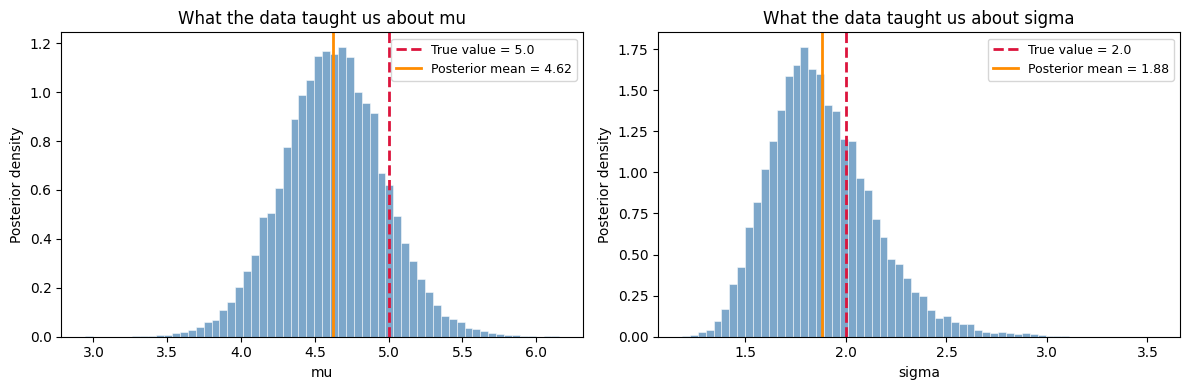

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, param, true_val in zip(axes, ["mu", "sigma"], [TRUE_POSITION, MEASUREMENT_NOISE]):
    posterior_values = idata.posterior[param].values.flatten()
    ax.hist(posterior_values, bins=60, density=True, alpha=0.7, color="steelblue",
            edgecolor="white", linewidth=0.5)
    ax.axvline(true_val, color="crimson", linestyle="--", linewidth=2,
               label=f"True value = {true_val}")
    ax.axvline(posterior_values.mean(), color="darkorange", linewidth=2,
               label=f"Posterior mean = {posterior_values.mean():.2f}")
    ax.set_xlabel(param)
    ax.set_ylabel("Posterior density")
    ax.set_title(f"What the data taught us about {param}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

These are **posterior distributions** -- the Bayesian answer to "where is the
star?" and "how noisy are our measurements?" They capture not just our best
guess (the peak) but our full uncertainty (the spread).

Notice that the true values (crimson dashes) fall squarely within the
posteriors. The model has learned the truth from the data, and it *knows*
how uncertain it is.

## The Trace: Watching MCMC Explore

Where did these posterior samples come from? Each of our four chains started
from a different random location and independently explored the space of
plausible parameter values. The **trace plot** shows this journey:

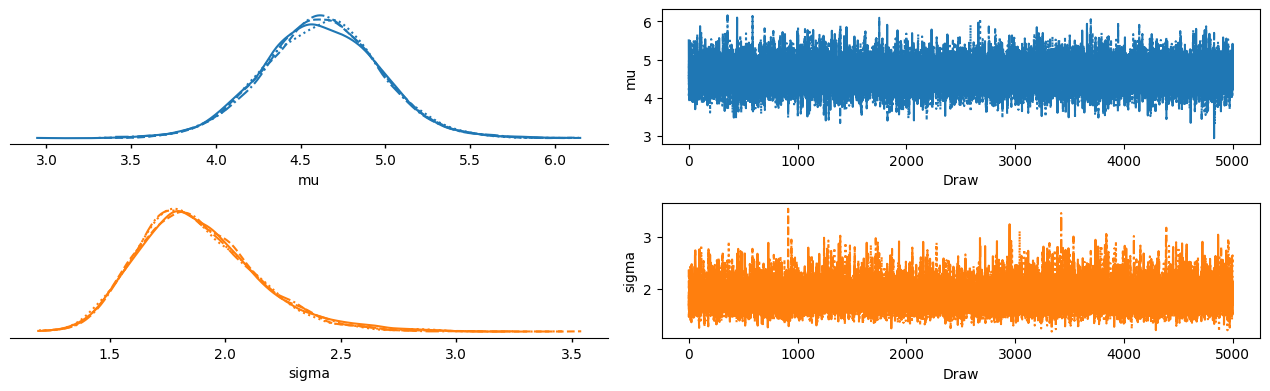

In [11]:
az.plot_trace_dist(idata, var_names=["mu", "sigma"])
plt.tight_layout()
plt.show()

The density plots (left column) show each chain's estimate of the
posterior -- all four chains should overlap, confirming they found the
same distribution. The trace plots (right column) show the sampled
values over time. Well-mixed chains look like "hairy caterpillars" --
rapidly oscillating with no trends or stuck periods.

If the chains had *not* converged, we would see them stuck in different
regions or drifting slowly. We will encounter such pathologies in later
notebooks -- and learn how to fix them.

## The Power of Updating: Watch Beliefs Sharpen

Here is perhaps the most beautiful property of Bayesian inference.
Let's see what happens as we give the model more and more data.
With 5 measurements, we're quite uncertain. With 10, less so. With all
30, the posterior is sharp and confident.

This is Bayes' theorem in action -- **beliefs sharpen with evidence:**

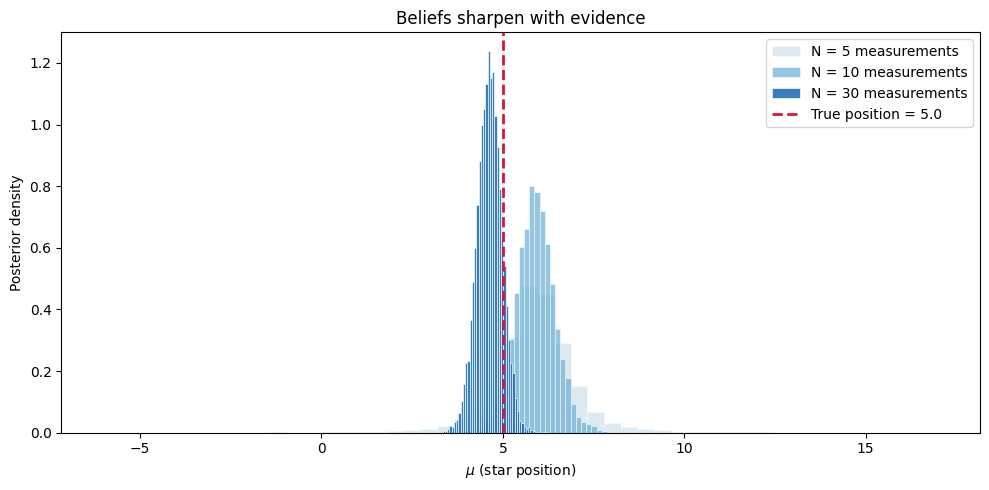

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#bdd7e7", "#6baed6", "#2171b5"]

for n, color, alpha in zip([5, 10, 30], colors, [0.5, 0.7, 0.9]):
    subset = measurements[:n]
    m = pyjags.Model(
        code=model_code,
        data=dict(y=subset, N=len(subset)),
        chains=4, adapt=500, progress_bar=False, seed=42,
    )
    m.sample(500, vars=[])
    s = m.sample(3000, vars=["mu"])
    mu_samples = s["mu"].flatten()
    ax.hist(mu_samples, bins=50, density=True, alpha=alpha, color=color,
            edgecolor="white", linewidth=0.5, label=f"N = {n} measurements")

ax.axvline(TRUE_POSITION, color="crimson", linestyle="--", linewidth=2,
           label=f"True position = {TRUE_POSITION}")
ax.set_xlabel(r"$\mu$ (star position)")
ax.set_ylabel("Posterior density")
ax.set_title("Beliefs sharpen with evidence")
ax.legend()
plt.tight_layout()
plt.show()

With 5 measurements (light blue), we're uncertain -- the star could be
anywhere from about 3 to 8. With 30 measurements (dark blue), the posterior
has collapsed around the truth. *This* is Bayesian learning: every data
point sharpens our beliefs, and the posterior tells us exactly how much we
know at every stage.

No frequentist confidence interval can do this. A confidence interval
answers a different question ("if I repeated the experiment many times,
how often would the interval contain the true value?"). The Bayesian
posterior answers the question you actually care about: **given the data I
have, where is the star?**

## Reproducibility: Same Seed, Same Universe

MCMC is inherently random -- it *samples* from the posterior. But science
demands reproducibility. The `seed` parameter ensures that two runs with
the same seed produce identical results, using `numpy.random.SeedSequence`
to derive independent seeds for each chain:

In [13]:
m1 = pyjags.Model(code=model_code, data=data, chains=4, adapt=1000,
                   progress_bar=False, seed=42)
m1.sample(1000, vars=[])
s1 = m1.sample(1000, vars=["mu"])

m2 = pyjags.Model(code=model_code, data=data, chains=4, adapt=1000,
                   progress_bar=False, seed=42)
m2.sample(1000, vars=[])
s2 = m2.sample(1000, vars=["mu"])

print(f"Results identical: {np.array_equal(s1['mu'], s2['mu'])}")

Results identical: True


## Loading Models from Files

For larger models, you can store the BUGS code in a `.bug` file and pass
the path. Both strings and `pathlib.Path` objects work:

In [14]:
from pathlib import Path
import tempfile

model_file = Path(tempfile.mktemp(suffix=".bug"))
model_file.write_text(model_code)

model_from_file = pyjags.Model(file=model_file, data=data, chains=4,
                                adapt=1000, progress_bar=False)
print(model_from_file)

model_file.unlink()  # clean up

Model(chains=4, variables=5, iteration=1000, adapted=True)


## What Comes Next

We have seen the fundamental Bayesian act: start with uncertainty
(the prior), observe evidence (the data), and arrive at updated beliefs
(the posterior). Bayes' theorem is the engine. MCMC is the fuel.
PyJAGS is the vehicle.

But we only scratched the surface. In our simple model, each measurement
was independent and each parameter stood alone. In the real world, data
comes in groups -- schools within districts, patients within hospitals,
counties within states. These groups share information, and a Bayesian
model can *borrow strength* across them.

In 1955, the mathematician Charles Stein proved something that stunned the
statistical world: when you estimate three or more means simultaneously,
the obvious approach -- estimate each one separately -- is *always*
beaten by an estimator that borrows information across the group. Nobody
believed it. It seemed to violate common sense. But it pointed toward a
profound truth that would eventually become the heart of Bayesian
statistics.

In the **Eight Schools** notebook, we will see Stein's paradox come to
life through a famous dataset, and discover why **partial pooling** -- the
hierarchical Bayesian model -- is arguably the single most important idea
in modern statistics.

---

**Further reading:**
- [JAGS User Manual](https://mcmc-jags.sourceforge.io/) -- the BUGS
  modeling language and JAGS distributions
- [ArviZ Documentation](https://python.arviz.org/) -- Bayesian analysis
  and visualization in Python
- McGrayne, *The Theory That Would Not Die* (2011) -- the fascinating
  history of Bayes' theorem from 1740 to the 21st century